In [1]:
# Set up the function needed to show stats and plotting below. 

from bunch import bunchify

import httplib2 as http
import json
import numpy as np
import matplotlib.pyplot as plt

BASE_URL = "http://localhost:18000"

def get_test_runs():
  h = http.Http()
  response, content = h.request(BASE_URL + "/json/ctsresult", "GET")
  return [bunchify(x) for x in json.loads(content)]

def get_test_run_details(run_id):
  h = http.Http()
  response, content = h.request(BASE_URL + "/json/ctsresult/" + run_id, "GET")
  return bunchify(json.loads(content))

def get_test_results(test_run_id, device_id):
  h = http.Http()
  url = "%s/json/ctsresult/%s/%s" % (BASE_URL, test_run_id, device_id)
  response, content = h.request(url, "GET")
  return bunchify(json.loads(content))

class StatsContainer(object):
  def __init__(self):
    self.combined = []
    self.pixel = []
    self.percent = []
    self.maxRGBA = []

  def add(self, closest):
    self.combined.append(closest.diffs.combined)
    self.pixel.append(closest.diffs.pixel)
    self.percent.append(closest.diffs.percent)
    self.maxRGBA.extend(closest.maxRGBADiffs)

def print_pass_fails(tests, failFn):
  statsObj = StatsContainer()

  passCount = 0
  noDiffs = 0
  for oneTest in tests:
    # Ignore tests for which we have not results.
    if len(oneTest.diffs) == 0:
      print ".  %s  ...........    FAIL (no closests)" % oneTest.name
      noDiffs += 1
      continue

    # Account for pass and fails
    testPasses = not failFn(oneTest)
    best =  oneTest.diffs[oneTest.closestDiffIdx]
    print "o  %s  ...........    %s             %f %f %f  %s" % (oneTest.name, "FAIL" if testPasses else "PASS", best.diffs.combined, best.diffs.percent, best.diffs.pixel, best.maxRGBADiffs)
    if testPasses:
      passCount += 1
    elif best:
      statsObj.add(best)


  print "Total tests: %d  Pass: %d   Fail: %d    No diffs: %d" % (len(tests), passCount, len(tests)-noDiffs-passCount, noDiffs)
  return statsObj

In [2]:
# Fetch the target data. 
test_runs = get_test_runs()
targetRunID = "testrun-1507554105762"
test_run = [x for x in test_runs if x.id == targetRunID][0]
test_run = get_test_run_details(test_run.id)
print "Target test run retrieved."

ref_dev_id = "sailfish"
tests_ref_dev = get_test_results(test_run.id, ref_dev_id)
print "Test results loaded for ref device"

absoluteFailFn = lambda oneTest: (len(oneTest.diffs) == 0) or (oneTest.diffs[oneTest.closestDiffIdx].diffs.combined > 0)
statsObj = print_pass_fails(tests_ref_dev, absoluteFailFn)


Target test run retrieved.
Test results loaded for ref device
o  3x3bitmaprect  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  BlurDrawImage  ...........    PASS             4.300056 29.821777 19544.000000  [136, 251, 136, 0]
o  CubicStroke  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  OverStroke  ...........    PASS             1.732031 9.920000 24800.000000  [87, 93, 87, 0]
o  PlusMergesAA  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  aaclip  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  aarectmodes  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  aaxfermodes  ...........    PASS             0.680253 0.742764 4568.000000  [165, 192, 192, 0]
o  addarc  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  addarc_meas  ...........    FAIL             0.000000 0.000000 0.000000  [0, 0, 0, 0]
o  all_bitmap_configs  ....

In [3]:
%matplotlib inline

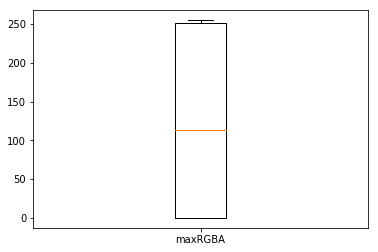

In [14]:
plot_data = [statsObj.combined, statsObj.pixel, statsObj.percent, statsObj.maxRGBA]
plot_labels = ["combined", "pixel", "percent", "maxRGBA"]
plot_data = [statsObj.maxRGBA]
plot_labels = ["maxRGBA"]
_ = plt.boxplot(plot_data, labels=plot_labels)